In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import dabest
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 54.48it/s]

Numba compilation complete!


# functions

In [2]:
def totalplot(tpath1, genotype, conc):
    """Process speed data for a genotype at a given ATR concentration."""
    df = pd.read_csv(tpath1 + genotype + ".csv")
    df = df.drop(columns=df.columns[0], axis=1)

    rr = df.copy()
    
    rr['Timer'] = 60
    rr.loc[df['second'] < 50.0, 'Timer'] = 50
    rr.loc[df['second'] < 40.0, 'Timer'] = 40
    rr.loc[df['second'] < 30.0, 'Timer'] = 30
    rr.loc[df['second'] < 20.0, 'Timer'] = 20
    rr.loc[df['second'] < 10.0, 'Timer'] = 10
    
    dff2 = pd.DataFrame()
    dff2[' Timer'] = rr['Timer']
    word = str(conc) + "x_.*"
        
    test2 = rr.filter(regex=genotype + ".*")
    dff2 = pd.concat([dff2, test2.filter(regex=word)], axis=1)

    trp = pd.DataFrame()
    for f in range(10, 70, 10):
        sp = dff2.iloc[:, 1:][(dff2[' Timer'] == f)].mean(axis=0).reset_index()
        sp.rename(columns={sp.columns[1]: "metric"}, inplace=True)
        sp["group"] = genotype + " " + str(f)
        sp["category"] = genotype + " " + str(conc) + "x ATR" + "_" + str(f)
        sp['timer'] = str(f)
        sp['conc'] = str(conc)
        sp['genre'] = genotype
        trp = pd.concat([trp, sp], axis=0)
        
    return trp.reset_index(drop=True)

# basic

In [9]:
homecomp = "D:\\"
labcomp = "C:\\Users\\User\\"

specifiedpath = labcomp
dropboxpath = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Worm tracking\\ML\\Processed\\Reprocced\\"
tpath1 = specifiedpath + dropboxpath
genotype = "KCR1GS"
wt_genotype = "WT-Green"

if genotype == "KCR1-ET":
    colorp = "#2d5016"
if genotype == "ACR":
    colorp = "#e66a2f"
if genotype == "KCR2":
    colorp = "#3182ce"
if genotype == "KCR1GS":
    colorp = "#59318d"
if "WT" in genotype:
    colorp = "#575757"

    
df = pd.read_csv(tpath1 + genotype+ ".csv")
df = df.drop(columns=df.columns[0], axis=1)

In [10]:
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

## Dabest plots

In [11]:
concentrations = [0, 0.5, 1, 2, 4] 
newtott = pd.DataFrame()
for conc in concentrations:
    main = totalplot(tpath1, genotype, conc)
    newtott = pd.concat([newtott, main], axis=0).reset_index(drop=True)    
wer = newtott[newtott['timer'] == '20']

In [12]:
p5 = dabest.load(wer, idx=(genotype +" 0x ATR_20", genotype +" 0.5x ATR_20", genotype +" 1x ATR_20", genotype +" 2x ATR_20", genotype +" 4x ATR_20"), x = "category", y = "metric", id_col = "index")
results = p5.mean_diff.results
#renaming for sample size and xlim names
atr_0_n = results.loc[0, 'control_N']  
atr_05_n = results.loc[0, 'test_N']  
atr_1_n  = results.loc[1, 'test_N']  
atr_2_n = results.loc[2, 'test_N']  
atr_4_n = results.loc[3, 'test_N'] 


atr_0_name= results.loc[0,"control"].split("_")[0].replace(genotype + " ", "")
atr_05_name = results.loc[0,"test"].split("_")[0].replace(genotype + " ", "")
atr_1_name = results.loc[1,"test"].split("_")[0].replace(genotype + " ", "")
atr_2_name = results.loc[2,"test"].split("_")[0].replace(genotype + " ", "")
atr_4_name = results.loc[3,"test"].split("_")[0].replace(genotype + " ", "")

c:\Users\User\anaconda3\envs\20250930version\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\envs\20250930version\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\User\anaconda3\envs\20250930version\Lib\site-packages\dabest\_effsize_objects.py:323: UserWarning: The lower limit of the BCa interval cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
c:\Users\User\anaconda3\envs\20250930version\Lib\site-packages\dabest\_effsize_objects.py:327: UserWarning: The upper limit of the BCa interval cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="upper"), stacklev

ZeroDivisionError: division by zero

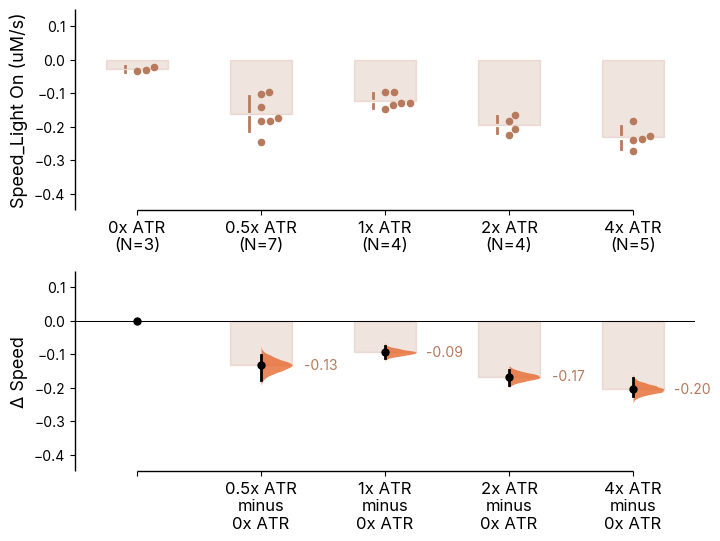

In [ ]:
import matplotlib as mpl
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 5,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 5}

graph0 = p5.mean_diff.plot(raw_label="Speed_Light On (uM/s)", **common_style,fig_size=(8, 6),
                                    contrast_label="Δ Speed", raw_marker_size=5, raw_ylim = (-0.45,0.15), 
                                    contrast_ylim=(-0.45, 0.15), custom_palette=[colorp]*5);

graph0.axes[1].spines['bottom'].set_visible(False)

graph0.axes[0].set_xticklabels([f"{atr_0_name}\n(N={atr_0_n})", 
                                f"{atr_05_name}\n(N={atr_05_n})",
                               f"{atr_1_name}\n(N={atr_2_n})",
                                f"{atr_2_name}\n(N={atr_2_n})",
                                f"{atr_4_name}\n(N={atr_4_n})" ], fontsize=12)

graph0.axes[1].set_xticklabels([" ", 
                                f"{atr_05_name}\nminus\n{atr_0_name}",
                               f"{atr_1_name}\nminus\n{atr_0_name}",
                                f"{atr_2_name}\nminus\n{atr_0_name}",
                                f"{atr_4_name}\nminus\n{atr_0_name}" ], fontsize=12)

mpl.rcParams['svg.fonttype'] = 'none' 
#graph0.savefig(os.path.join(tpath1, "Dabest plots\\",  'Dabest plots for increasing concentrations across ' + genotype + ' same genotype.svg'), dpi = 300)

## Comparing WT ATR at same concentrations


In [ ]:
lstofgenotypes = ['ACR', 'KCR1-ET', 'KCR2', 'KCR1GS']
newtott = pd.DataFrame()
for n in lstofgenotypes:
    for conc in [0, 1]:
        main = totalplot(tpath1, n, conc)
        newtott = pd.concat([newtott, main], axis=0).reset_index(drop=True)
         
wtmain_0 = totalplot(tpath1, wt_genotype, 0)   
wtmain_1 = totalplot(tpath1, wt_genotype, 1)   
newtott = pd.concat([newtott, wtmain_0, wtmain_1], axis=0).reset_index(drop=True) 
wer = newtott[newtott['timer'] == '20']

In [11]:
p5 = dabest.load(wer, idx=(("WT-Green 0x ATR_20","WT-Green 1x ATR_20"), 
                           ('ACR 0x ATR_20', 'ACR 1x ATR_20'), 
                           ('KCR1-ET 0x ATR_20', 'KCR1-ET 1x ATR_20'), 
                           ('KCR2 0x ATR_20', 'KCR2 1x ATR_20'),
                           ('KCR1GS 0x ATR_20', 'KCR1GS 1x ATR_20')), 
                 x = "category", y = "metric", id_col = "index")
results = p5.mean_diff.results
#renaming for sample size and xlim names
atr_wt0 = results.loc[0, 'control_N']  
atr_wt1 = results.loc[0, 'test_N']  

atr_acr0 = results.loc[1, 'control_N']  
atr_acr1 = results.loc[1, 'test_N']  

atr_kcr10 = results.loc[2, 'control_N']  
atr_kcr11 = results.loc[2, 'test_N']  

atr_kcr20 = results.loc[3, 'control_N']  
atr_kcr21 = results.loc[3, 'test_N']  

atr_kcrgs1 = results.loc[4, 'control_N']  
atr_kcrgs2 = results.loc[4, 'test_N']  

#naming for swarm plots
swarm_wt0= results.loc[0,"control"].split(" ")[1]
swarm_wt1= results.loc[0,"test"].split(" ")[1]

swarm_acr0= results.loc[1,"control"].split(" ")[1]
swarm_acr1= results.loc[1,"test"].split(" ")[1]

swarm_kcr10= results.loc[2,"control"].split(" ")[1]
swarm_kcr11= results.loc[2,"test"].split(" ")[1]

swarm_kcr20= results.loc[3,"control"].split(" ")[1]
swarm_kcr21= results.loc[3,"test"].split(" ")[1]

swarm_kcrgs1= results.loc[4,"control"].split(" ")[1]
swarm_kcrgs2= results.loc[4,"test"].split(" ")[1]

#naming for contrast plots
contrast1= results.loc[0,"control"].split(" ")[0]
contrast2= results.loc[1,"control"].split(" ")[0]
contrast3= results.loc[2,"control"].split(" ")[0]
contrast4= results.loc[3,"control"].split(" ")[0]
contrast5= results.loc[4,"control"].split(" ")[0]

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 28.6% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


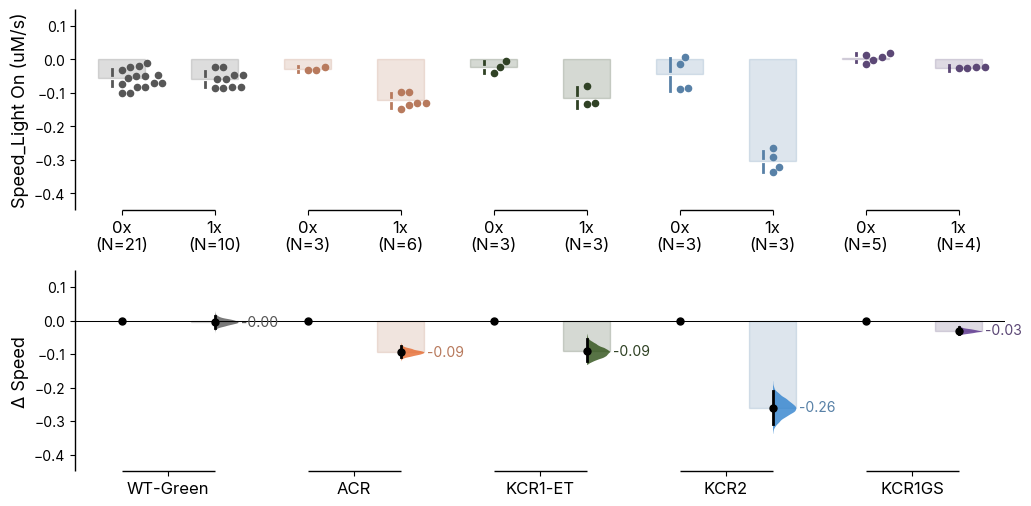

In [14]:
import matplotlib as mpl
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 5,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 5}

graph0 = p5.mean_diff.plot(raw_label="Speed_Light On (uM/s)", fig_size=(12, 6),
                                    contrast_label="Δ Speed", raw_marker_size=5, raw_ylim = (-0.45,0.15), 
                                    contrast_ylim=(-0.45, 0.15), custom_palette=['#575757', '#575757', '#e66a2f', '#e66a2f', 
                    '#2d5016', '#2d5016', '#3182ce', '#3182ce', '#59318d','#59318d'],  
                                    **common_style );

graph0.axes[1].spines['bottom'].set_visible(False)

graph0.axes[0].set_xticklabels([f"{swarm_wt0}\n(N={atr_wt0})", 
                                f"{swarm_wt1}\n(N={atr_wt1})",
                               f"{swarm_acr0}\n(N={atr_acr0})",
                                f"{swarm_acr1}\n(N={atr_acr1})",
                                f"{swarm_kcr10}\n(N={atr_kcr10})",
                                f"{swarm_kcr11}\n(N={atr_kcr11})",
                                f"{swarm_kcr20}\n(N={atr_kcr10})",
                                f"{swarm_kcr21}\n(N={atr_kcr11})",
                                f"{swarm_kcrgs1}\n(N={atr_kcrgs1})",
                                f"{swarm_kcrgs2}\n(N={atr_kcrgs2})"], fontsize=12)
graph0.axes[1].set_xticks([0.5, 2.5, 4.5, 6.5, 8.5])
graph0.axes[1].set_xticklabels([contrast1, contrast2, contrast3, contrast4, contrast5 ], fontsize=12)

mpl.rcParams['svg.fonttype'] = 'none' 
graph0.savefig(os.path.join(tpath1, "Dabest plots\\",  'comparison on 1x ATR type.svg'), dpi = 300)